In [39]:
from datetime import datetime, timedelta
from freqtrade.strategy import IStrategy
import pandas as pd
import talib.abstract as ta
import numpy as np
import freqtrade.vendor.qtpylib.indicators as qtpylib

def generate_dummy_freqtrade_data(rows=100, timeframe='5m'):
     # 1. Create a timestamp range
    base_time = datetime(2023, 1, 1)
    dates = [base_time + timedelta(minutes=5 * i) for i in range(rows)]
    
    # 2. Generate synthetic price movement (Random Walk)
    np.random.seed(42)  # For reproducibility
    close_prices = 100 + np.cumsum(np.random.randn(rows) * 0.5)
    opens = close_prices + np.random.randn(rows) * 0.1
    highs = np.maximum(opens, close_prices) + np.random.rand(rows) * 0.2
    lows = np.minimum(opens, close_prices) - np.random.rand(rows) * 0.2
    volumes = np.random.randint(1000, 5000, size=rows).astype(float)
    # 3. Assemble the dataframe
    df = pd.DataFrame({
        'date': dates,
        'open': opens,
        'high': highs,
        'low': lows,
        'close': close_prices,
        'volume': volumes
        })
    return df

dataframe = generate_dummy_freqtrade_data(rows=100, timeframe='5m')
#display(dataframe)

<Axes: xlabel='date'>

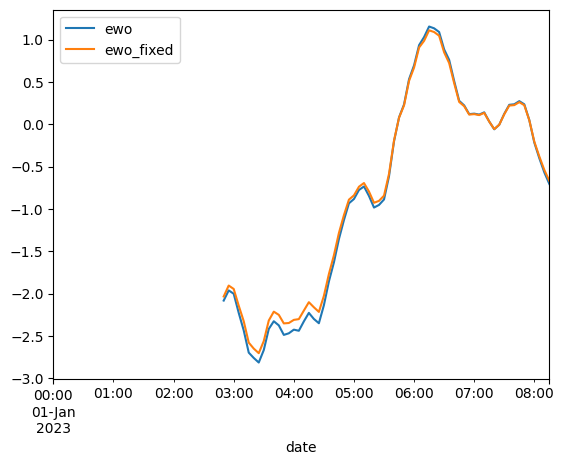

In [40]:
sma5 = ta.SMA(dataframe, timeperiod=5)
sma35 = ta.SMA(dataframe, timeperiod=35)
dataframe['ewo'] = (sma5 - sma35) / dataframe['close'] * 100   
dataframe['ewo_fixed'] = (sma5 - sma35)

# Plotting a line chart
dataframe.plot(x='date', y=['ewo','ewo_fixed'])





In [48]:
display(dataframe)

def populate_entry_trend(self, dataframe: pd.DataFrame, metadata: dict) -> pd.DataFrame:
    dataframe.loc[
        (
            (qtpylib.crossed_above(dataframe['ewo'], 0)) & # EWO turns positive
            (dataframe['volume'] > 0)                      # Ensure there is volume
        ),
        'enter_long'] = 1
    return dataframe

df = pd.DataFrame()

df = populate_entry_trend(dataframe)

display(dataframe)

,date,open,high,low,close,volume,ewo,ewo_fixed
0,2023-01-01 00:00:00,100.106820,100.423832,99.918527,100.248357,1189.0,NaN,NaN
1,2023-01-01 00:05:00,100.137160,100.327379,100.059940,100.179225,1504.0,NaN,NaN
2,2023-01-01 00:10:00,100.468798,100.642472,100.276560,100.503069,2214.0,NaN,NaN
3,2023-01-01 00:15:00,101.184356,101.405081,101.003286,101.264584,2531.0,NaN,NaN
4,2023-01-01 00:20:00,101.131379,101.219406,101.092221,101.147507,4440.0,NaN,NaN
...,...,...,...,...,...,...,...,...
95,2023-01-01 07:55:00,94.682355,94.797450,94.620060,94.643823,3871.0,0.049382,0.046737
96,2023-01-01 08:00:00,94.703498,94.869517,94.679992,94.791883,1797.0,-0.216728,-0.205440
97,2023-01-01 08:05:00,94.937783,95.066441,94.792569,94.922411,4313.0,-0.401213,-0.380841
98,2023-01-01 08:10:00,94.930789,95.022439,94.775759,94.924968,4322.0,-0.569003,-0.540126


TypeError: populate_entry_trend() missing 2 required positional arguments: 'dataframe' and 'metadata'

In [50]:
import pandas as pd
import talib.abstract as ta

def generate_test_metadata(pair='BTC/USDT', timeframe='5m'):
    """
    Creates a metadata dictionary mimicking the Freqtrade internal engine.
    """
    return {
        'pair': pair,
        'tf': timeframe
    }


# 1. Define a minimal version of your strategy class
class MyStrategy:
    def populate_indicators(self, dataframe: pd.DataFrame, metadata: dict) -> pd.DataFrame:
        # Using metadata to log or adjust logic
        pair = metadata.get('pair', 'Unknown')
        print(f"Calculating indicators for: {pair}")
        
        # Calculate EWO
        dataframe['sma_fast'] = ta.SMA(dataframe['close'], timeperiod=5)
        dataframe['sma_slow'] = ta.SMA(dataframe['close'], timeperiod=35)
        dataframe['ewo'] = dataframe['sma_fast'] - dataframe['sma_slow']
        
        return dataframe

# 2. Setup the test environment
strategy = MyStrategy()
mock_df = generate_dummy_freqtrade_data(rows=50) # From previous snippet
mock_metadata = generate_test_metadata(pair='SOL/USDT', timeframe='5m')

# 3. Simulate the Freqtrade call
processed_df = strategy.populate_indicators(mock_df, mock_metadata)

# 4. Inspect result
print(processed_df[['date', 'close', 'ewo']].tail())

Calculating indicators for: SOL/USDT
                  date      close       ewo
45 2023-01-01 03:45:00  94.774622 -2.251465
46 2023-01-01 03:50:00  94.544302 -2.352429
47 2023-01-01 03:55:00  95.072863 -2.347760
48 2023-01-01 04:00:00  95.244672 -2.310861
49 2023-01-01 04:05:00  94.363152 -2.301869
